# Llama 3 8B Coupling Demo
### Colab: https://colab.research.google.com/drive/1ronRmxr0yJO8Re0iJeqp055IoiU7oLOI?usp=sharing

In [1]:
!pip install bitsandbytes datasets
!pip install -U bitsandbytes

### Helper functions

In [2]:
import os
import time
from datetime import datetime
from collections import defaultdict

import torch
from torch.autograd import grad
from functorch.experimental import chunk_vmap

from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig
import datasets
import bitsandbytes

def timestamp(*args):
    now = datetime.now()
    current_time = now.strftime("%H:%M:%S")
    label = " ".join(map(str, args))
    print(str(current_time) + ": " + label, flush=True)

def jacobian(output, input, index, chunks, index_in=None, verbose=False, device="cuda"):
    """
    Computes the Jacobian of `d{output}/d{input}` from transformer hooks
    by vectorizing over gradients.

    output:     Jacobian wrt this output
    input:      Jacobian wrt this input
    index:      index of output token
    chunks:     number of chunks used to vectorize Jacobian computation
    index_in:   (optional) changes input token of Jacobian if not `index`
    """
    tt = time.time()

    output = output[0, index, :]
    I_N = torch.eye(output.numel()).to(device)

    index_in = index_in if index_in is not None else index
    def get_vjp(v):
        return grad(output, input, v, retain_graph=True)[0][0, index_in, :]

    jacobian = chunk_vmap(get_vjp, chunks=chunks)(I_N)
    print(f"Jacobian computed in {time.time()-tt:.3f} seconds") if verbose else None

    return jacobian

def svd(Jac, method="torch", K=50, L=20, E=5, ITS=20, verbose=False):
    """
    Computes the SVD of a list of Jacobians.

    Jac:        list of Jacobians
    method:
    -   "torch" calls `torch.linalg.svd()`
    -   "random" calls random SVD (implemented below),
        - if using "random", `K, L, E, ITS` will be used
    """
    if method == "torch":
        Us, Ss, Vs = [], [], []
        for j in range(len(Jac)):
            i = j
            tt = time.time()
            timestamp('svding layer {}'.format(i))
            U, S, V = torch.linalg.svd(Jac[i])
            Us.append(U)
            Ss.append(S)
            Vs.append(V)
            print(f"SVD computed in {time.time()-tt:.3f} seconds") if verbose else None
    elif method == "random":
        Us, Ss, Vs = randomsvd(Jac, K=K, L=L, E=E, ITS=ITS)
    else:
        raise NotImplementedError("Only torch SVD is implemented")
    return Us, Ss, Vs

def metrics(Jac, Us=None, Ss=None, Vs=None, p=2, num_sing_vecs=(10,30,50),
            L=20, E=5, ITS=20, device="cpu"):

    aln_ujv_all_k = {}
    aln_vju_all_k = {}

    # do torch SVD by default
    if Us is None or Ss is None or Vs is None:
        Us, Ss, Vs = svd(Jac)

    S = torch.stack(Ss).cpu()
    U_all = [u.to(device) for u in Us]
    V_all = [v.to(device) for v in Vs]
    J = [j.to(device) for j in Jac]

    for K in num_sing_vecs:
        U, V = [u[:, :K] for u in U_all], [v[ :K, :].T for v in V_all]

        ujv_mat_trace = torch.zeros((len(S), len(S)))
        vju_mat_trace = torch.zeros((len(S), len(S)))

        ujv_mat_norm = torch.zeros((len(S), len(S)))
        vju_mat_norm = torch.zeros((len(S), len(S)))

        # print(S[0].shape)

        for i in range(len(S)):
            for j in range(len(S)):
                uj, ji, vj = U[j], J[i], V[j]
                # ui, vi = U[i], V[i]
                if uj.shape[0] != ji.shape[1] or vj.shape[0] != ji.shape[0]:
                    print("wrong shape")
                    continue

                S_i = torch.diag(S[i][:K])

                ujv_mat_trace[i, j], ujv_mat_norm[i, j] = diag_sv_trace_similarity(ji, S_i, uj, vj, p=p)
                vju_mat_trace[i, j], vju_mat_norm[i, j] = diag_sv_trace_similarity(ji, S_i, vj, uj, p=p)

        aln_ujv_all = {}
        aln_ujv_all['trace'] = ujv_mat_trace
        aln_ujv_all['norm'] = ujv_mat_norm

        aln_vju_all = {}
        aln_vju_all['trace'] = vju_mat_trace
        aln_vju_all['norm'] = vju_mat_norm

        aln_ujv_all_k[K] = aln_ujv_all
        aln_vju_all_k[K] = aln_vju_all

    return aln_ujv_all_k, aln_vju_all_k

def diag_sv_trace_similarity(J1, S1, U2, V2, p=2): # swap U2 and V2 for the vju case
    M = U2.T @ J1 @ V2
    tr = torch.trace(S1)
    norm = torch.norm(torch.diag(S1), p=p)
    diff = torch.linalg.norm(torch.abs(M)-S1)
    return diff / tr, diff / norm

### Coupling Methods

In [3]:
def coupling_from_hooks(hooks, p=2, num_sing_vecs=(10,30,50), index=-1, index_in=None,
    activation=None, chunks=4, verbose=False, device="cuda"):
    """
    Computes the coupling of residual Jacobians across hooks.

    hooks:      dict of representations before and after skip connection
    - hooks[layer] = {0: x_in, 1: x_out}
    p:              order of p-norm for coupling measurement
    num_sing_vecs:  number of top singular vectors to use in computing coupling
    index:          output token index for Jacobian
    index_in:       input token index for Jacobian
    - by default uses `index`
    activation: specifies whether to apply activation to `x_out` before computing Jacobian
    chunks:     number of chunks in Jacobian computation
    """
    Jac = []

    for h in hooks:
        timestamp("computing J of: ", h) if verbose else None

        x_in = hooks[h][0]
        x_out = hooks[h][1]
        dim = x_out.shape[-1]

        if activation is None:
            J = jacobian(x_out, x_in, index=-1, device="cuda", chunks=chunks).detach()
            Jac.append(J - torch.eye(dim).to(device))
            timestamp("Jacobian shape ", J.shape) if verbose else None
        else:
            J = jacobian(activation(x_out), x_in, index=index, index_in=index_in, device="cuda").detach()
            Jac.append(J - torch.eye(dim).to(device))

    timestamp("Computing coupling metrics") if verbose else None

    Us, Ss, Vs = svd(Jac)
    coupling_ujv, coupling_vju = metrics(Jac, Us, Ss, Vs, p=p, num_sing_vecs=num_sing_vecs)

    return coupling_ujv, coupling_vju

def run_coupling_hf(model, tokenizer, model_name, prompts, start=None, end=None, \
        save=False, out_path=None, device="cuda", verbose=False):
    """
    Runs coupling experiment for HuggingFace model and tokenizer. (See `demo/minimal_demo_hf.py`)

    model:      model following HuggingFace API
    tokenizer:  tokenizer of model
    model_name: model name, e.g. `Meta-Llama-3-8B`
    promtpts:   list of str prompts to pass to tokenizer
    """
    out = defaultdict(dict)
    start = start if start is not None else 0
    end = end if end is not None else len(prompts)

    for i, prompt in zip(range(start, end), prompts):
        timestamp(f"Running prompt {i + 1} of {end}")

        out[i] = {"prompt": prompt}
        print(prompt) if verbose else None

        tokens = tokenizer(prompt, return_tensors='pt')
        input_ids = tokens.input_ids
        num_tokens = input_ids.shape[1]
        print("Number of tokens:", num_tokens) if verbose else None

        chunks = 2 * (num_tokens // 20) + 5 + i
        print("Number of chunks:", chunks) if verbose else None

        input_ids = input_ids.to('cuda')
        outputs = model(input_ids, output_hidden_states=True)
        L = len(outputs.hidden_states) - 1

        # format as hooks
        outputs_zip = {}
        for j in range(L):
            outputs_zip[f"block_{j}"] = {0: outputs.hidden_states[j], 1: outputs.hidden_states[j+1]}

        # compute coupling
        coupling_ujv, coupling_vju = coupling_from_hooks(
            outputs_zip, activation=None, chunks=chunks, verbose=verbose, device=device
        )

        out[i]["coupling_ujv"] = coupling_ujv
        out[i]["coupling_vju"] = coupling_vju
        timestamp(f"Ended prompt") if verbose else None

    if save:
        if out_path is None:
            out_path = os.getcwd()
            print(f"Saving enabled but out_path path not specified. Saving in `{out_path}`")
        out_file = os.path.join(out_path, "_".join((model_name, "coupling.pt")))
        torch.save(out, out_file)

    return out

### Load HuggingFace Model

In [4]:
model_path = "meta-llama/Meta-Llama-3-8B"
model_name = os.path.normpath(os.path.basename(model_path))
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

model = AutoModelForCausalLM.from_pretrained(
            model_path,
            device_map="cuda",
            trust_remote_code=True,
            quantization_config=bnb_config
        )
tokenizer = AutoTokenizer.from_pretrained(
        model_path,
        use_fast=True,
    )

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

### Compute

In [5]:
prompts = ["What is the capital of France? The capital is"]
out = run_coupling_hf(model, tokenizer, model_name, prompts, save=True, verbose=False)

22:25:08: Running prompt 1 of 1


/usr/local/lib/python3.11/dist-packages/bitsandbytes/nn/modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_efficient_attention_backward. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:81.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


22:27:51: svding layer 0
22:28:01: svding layer 1
22:28:11: svding layer 2
22:28:20: svding layer 3
22:28:30: svding layer 4
22:28:40: svding layer 5
22:28:50: svding layer 6
22:28:59: svding layer 7
22:29:09: svding layer 8
22:29:18: svding layer 9
22:29:28: svding layer 10
22:29:38: svding layer 11
22:29:48: svding layer 12
22:29:57: svding layer 13
22:30:07: svding layer 14
22:30:16: svding layer 15
22:30:26: svding layer 16
22:30:35: svding layer 17
22:30:45: svding layer 18
22:30:55: svding layer 19
22:31:05: svding layer 20
22:31:14: svding layer 21
22:31:24: svding layer 22
22:31:34: svding layer 23
22:31:44: svding layer 24
22:31:54: svding layer 25
22:32:03: svding layer 26
22:32:13: svding layer 27
22:32:23: svding layer 28
22:32:33: svding layer 29
22:32:43: svding layer 30
22:32:53: svding layer 31
Saving enabled but out_path path not specified. Saving in `/content`


### Plot Coupling Matrix

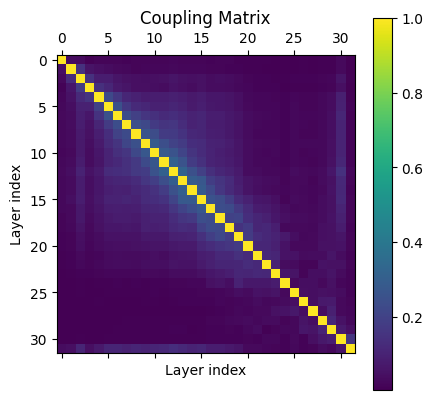

In [6]:
import matplotlib.pyplot as plt

coupling_matrix = 1-out[0]["coupling_ujv"][50]["norm"]**2
plt.matshow(coupling_matrix)
plt.colorbar()

plt.title("Coupling Matrix")
plt.xlabel("Layer index")
plt.ylabel("Layer index")

plt.show()